# Assignment: Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
from google.colab import files
uploaded = files.upload()

# Then load the data
gifts = pd.read_csv('ForeignGifts_edu.csv')
airbnb = pd.read_csv('airbnb_hw.csv')
rigs = pd.read_csv('drilling_rigs.csv')

Saving drilling_rigs.csv to drilling_rigs.csv
Saving airbnb_hw.csv to airbnb_hw.csv
Saving ForeignGifts_edu.csv to ForeignGifts_edu.csv


## Q1: Mathematical Properties

### 1.1: Show $m(a + bX) = a + b \times m(X)$

$$m(a + bX) = \frac{1}{N}\sum(a + bx_i) = \frac{1}{N}(Na + b\sum x_i) = a + b\cdot m(X)$$

### 1.2: Show $\text{cov}(X, a+bY) = b \times \text{cov}(X,Y)$

Since $m(a+bY) = a + b\cdot m(Y)$:
$$\text{cov}(X, a+bY) = \frac{1}{N}\sum(x_i - m(X))(a+by_i - a - b\cdot m(Y)) = b\cdot\text{cov}(X,Y)$$

### 1.3: Show $\text{cov}(a+bX, a+bX) = b^2\text{cov}(X,X)$ and $\text{cov}(X,X) = s^2$

Applying 1.2 twice: $\text{cov}(a+bX, a+bX) = b\cdot\text{cov}(X, a+bX) = b^2\cdot\text{cov}(X,X)$

$$\text{cov}(X,X) = \frac{1}{N}\sum(x_i - m(X))^2 = s^2$$

### 1.4: Non-decreasing transformations and median

**Yes**, for non-decreasing $g()$: $g(\text{median}(X)) = \text{median}(g(X))$

Proof: If 50% of values ≤ median($X$), then 50% of $g(x_i)$ ≤ $g($median($X$)$)$ since $g$ preserves order.

**Applies to all quantiles:** Yes - same logic applies to any percentile (IQR, range, etc.)

### 1.5: Is $m(g(X)) = g(m(X))$ for non-decreasing transformations?

**No.** Counterexample: $X = \{1,2,3\}$, $g(x) = x^2$
- $g(m(X)) = 2^2 = 4$
- $m(g(X)) = (1+4+9)/3 = 4.67$

Only true for linear transformations.

In [2]:
# Verify counterexample
X = np.array([1, 2, 3])
print(f"g(m(X)) = {X.mean()**2:.2f}")
print(f"m(g(X)) = {(X**2).mean():.2f}")

g(m(X)) = 4.00
m(g(X)) = 4.67


## Q2: Foreign Gifts to US Universities

In [6]:
# 2.1: Load data
gifts = pd.read_csv('/content/ForeignGifts_edu.csv')
print(f"Shape: {gifts.shape}")
gifts.head()

Shape: (28221, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


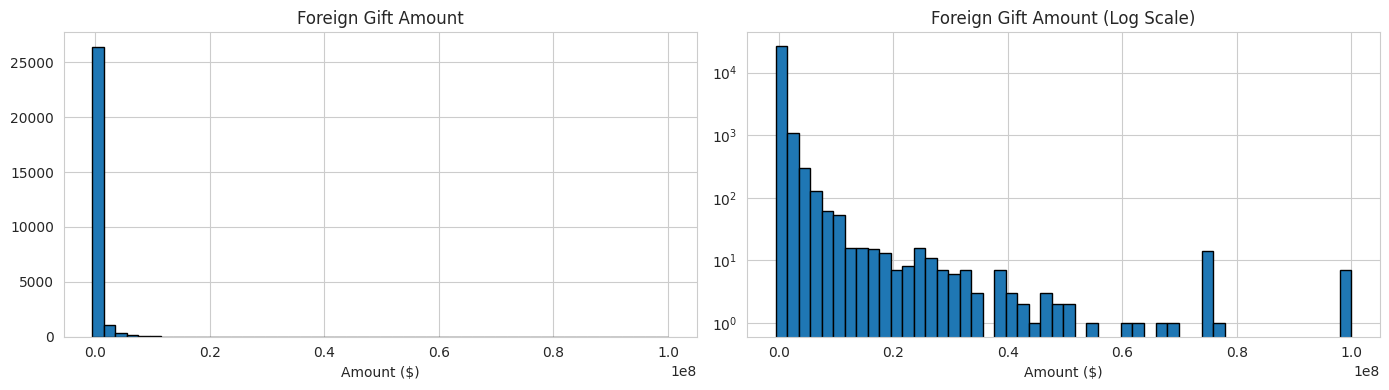


Findings: Heavily right-skewed distribution with extreme outliers. Median << Mean.


In [7]:
# 2.2: Histogram and description of Foreign Gift Amount
print(gifts['Foreign Gift Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(gifts['Foreign Gift Amount'], bins=50, edgecolor='black')
axes[0].set_title('Foreign Gift Amount')
axes[0].set_xlabel('Amount ($)')

axes[1].hist(gifts['Foreign Gift Amount'], bins=50, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Foreign Gift Amount (Log Scale)')
axes[1].set_xlabel('Amount ($)')
plt.tight_layout()
plt.show()

print("\nFindings: Heavily right-skewed distribution with extreme outliers. Median << Mean.")

Gift Type Proportions:
Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64


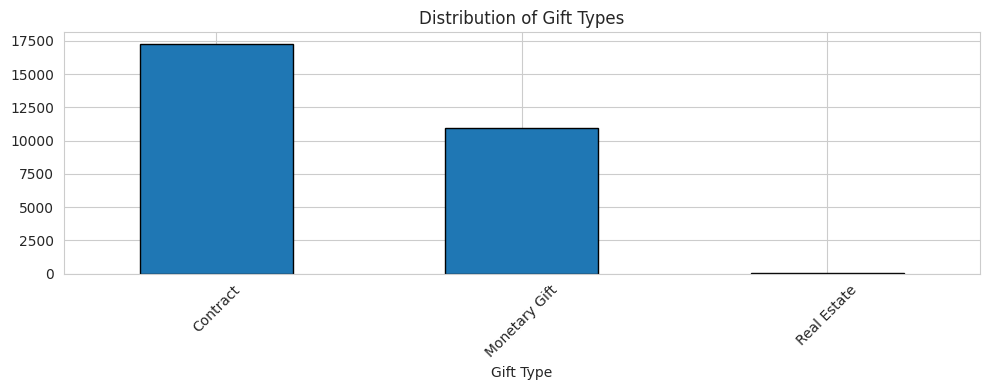

In [8]:
# 2.3: Gift Type distribution
gift_counts = gifts['Gift Type'].value_counts()
gift_props = gifts['Gift Type'].value_counts(normalize=True) * 100

print("Gift Type Proportions:")
print(gift_props)

plt.figure(figsize=(10, 4))
gift_counts.plot(kind='bar', edgecolor='black')
plt.title('Distribution of Gift Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

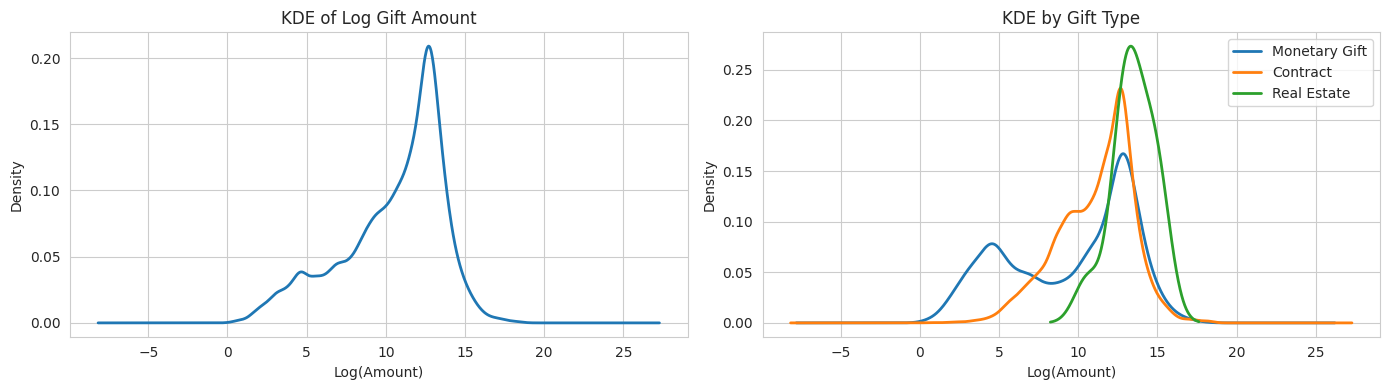

In [10]:
# 2.4: KDE plots of log gift amount
gifts['log_amount'] = np.log(gifts['Foreign Gift Amount'] + 1)

# Remove inf and NaN values for plotting
gifts_clean = gifts[np.isfinite(gifts['log_amount'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

gifts_clean['log_amount'].plot(kind='kde', ax=axes[0], linewidth=2)
axes[0].set_title('KDE of Log Gift Amount')
axes[0].set_xlabel('Log(Amount)')

for gift_type in gifts_clean['Gift Type'].unique():
    subset = gifts_clean[gifts_clean['Gift Type'] == gift_type]
    subset['log_amount'].plot(kind='kde', ax=axes[1], linewidth=2, label=gift_type)
axes[1].set_title('KDE by Gift Type')
axes[1].set_xlabel('Log(Amount)')
axes[1].legend()
plt.tight_layout()
plt.show()

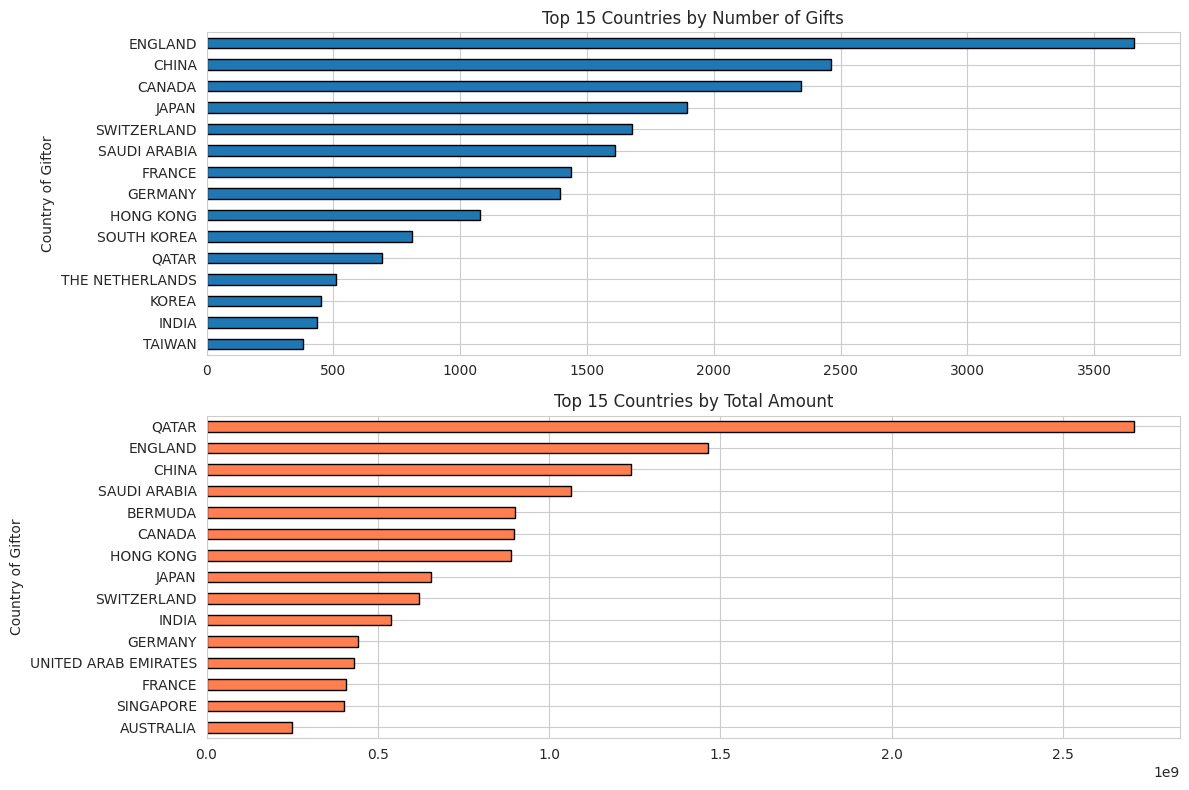

In [11]:
# 2.5: Top 15 countries
top_count = gifts['Country of Giftor'].value_counts().head(15)
top_amount = gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

top_count.plot(kind='barh', ax=axes[0], edgecolor='black')
axes[0].set_title('Top 15 Countries by Number of Gifts')
axes[0].invert_yaxis()

top_amount.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 15 Countries by Total Amount')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

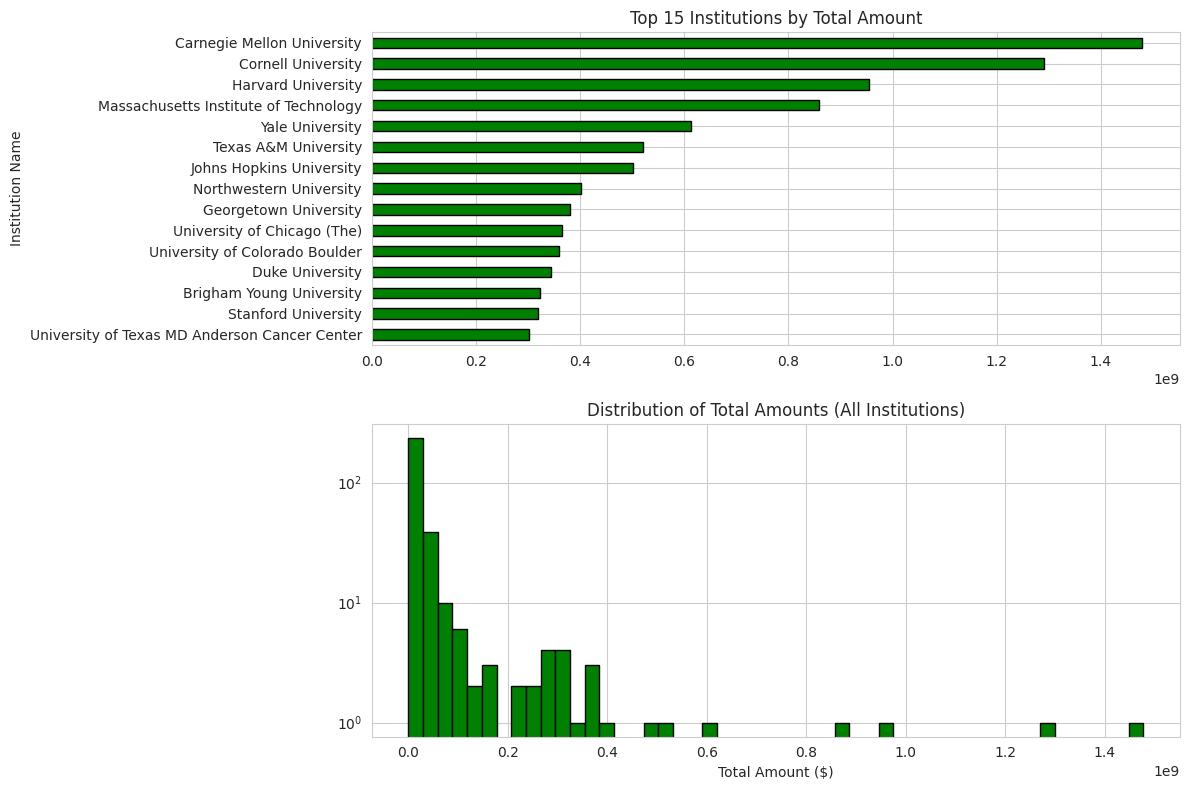

Top 15 capture 54.3% of total gifts


In [12]:
# 2.6: Top 15 institutions and histogram
top_inst = gifts.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
inst_totals = gifts.groupby('Institution Name')['Foreign Gift Amount'].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

top_inst.plot(kind='barh', ax=axes[0], color='green', edgecolor='black')
axes[0].set_title('Top 15 Institutions by Total Amount')
axes[0].invert_yaxis()

axes[1].hist(inst_totals, bins=50, edgecolor='black', color='green')
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Total Amounts (All Institutions)')
axes[1].set_xlabel('Total Amount ($)')

plt.tight_layout()
plt.show()

print(f"Top 15 capture {top_inst.sum() / gifts['Foreign Gift Amount'].sum() * 100:.1f}% of total gifts")

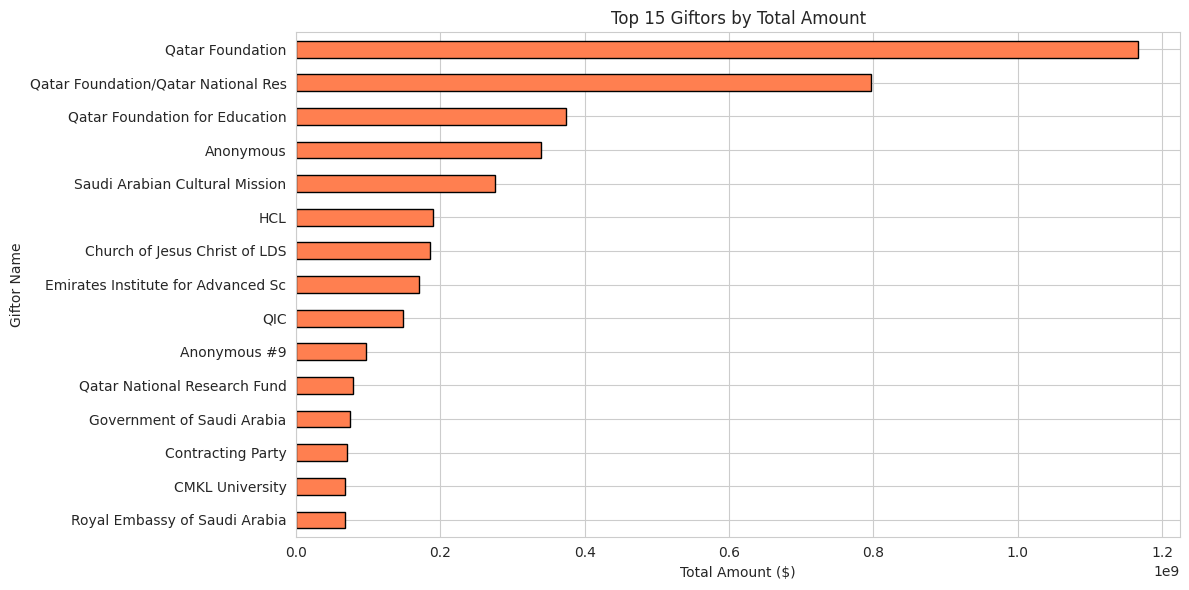

In [13]:
# 2.7: Top giftors
top_giftors = gifts[gifts['Giftor Name'].notna()].groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
top_giftors.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 15 Giftors by Total Amount')
plt.xlabel('Total Amount ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q3: Airbnb Data

In [14]:
# 3.1 & 3.2: Load and examine
airbnb = pd.read_csv('/content/airbnb_hw.csv')
print(f"Dimensions: {airbnb.shape}")
print(f"Variables: {airbnb.columns.tolist()}")
airbnb.head()

Dimensions: (30478, 13)
Variables: ['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type', 'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Price', 'Review Scores Rating']


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


Counts:
Room Type        Entire home/apt  Private room  Shared room
Property Type                                              
Apartment                  15669         10748          685
Bed & Breakfast               13           155           12
Boat                           7             1            0
Bungalow                       4             0            0
Cabin                          1             1            0
Camper/RV                      6             1            0
Castle                         0             1            0
Chalet                         0             1            0
Condominium                   72            22            0
Dorm                           4            16           11
House                        752          1258           80
Hut                            0             2            0
Lighthouse                     1             0            0
Loft                         392           312           49
Other                         14

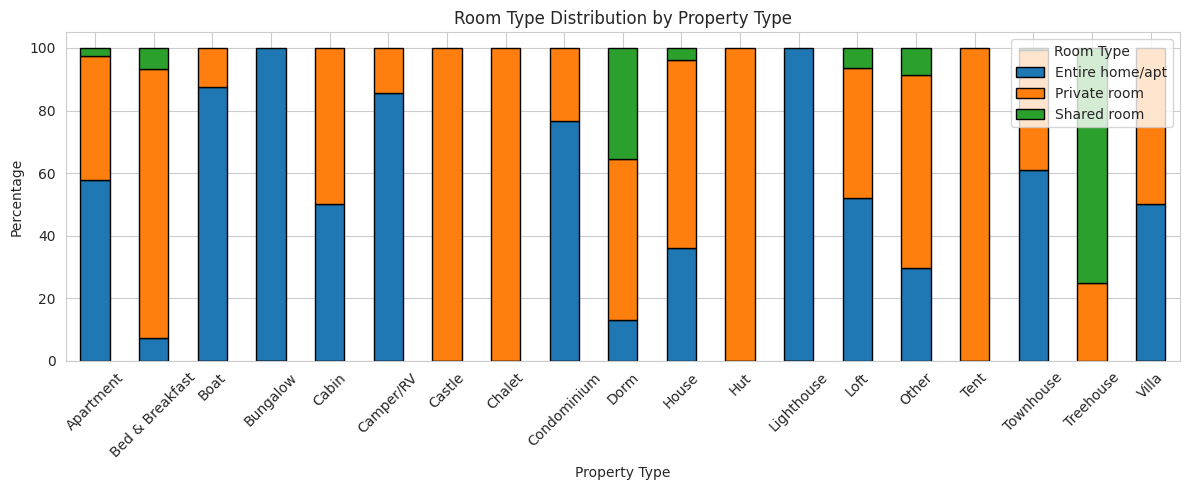


Pattern: Private rooms more common in houses, condos, townhouses vs apartments.


In [15]:
# 3.3: Cross tabulation
cross_tab = pd.crosstab(airbnb['Property Type'], airbnb['Room Type'])
cross_tab_pct = pd.crosstab(airbnb['Property Type'], airbnb['Room Type'], normalize='index') * 100

print("Counts:")
print(cross_tab)
print("\nProportions (%):")
print(cross_tab_pct.round(1))

cross_tab_pct.plot(kind='bar', stacked=True, figsize=(12, 5), edgecolor='black')
plt.title('Room Type Distribution by Property Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nPattern: Private rooms more common in houses, condos, townhouses vs apartments.")

Log(Price):
count    30297.000000
mean         4.845370
std          0.596999
min          2.302585
25%          4.382027
50%          4.828314
75%          5.257495
max          6.906755
Name: price_log, dtype: float64


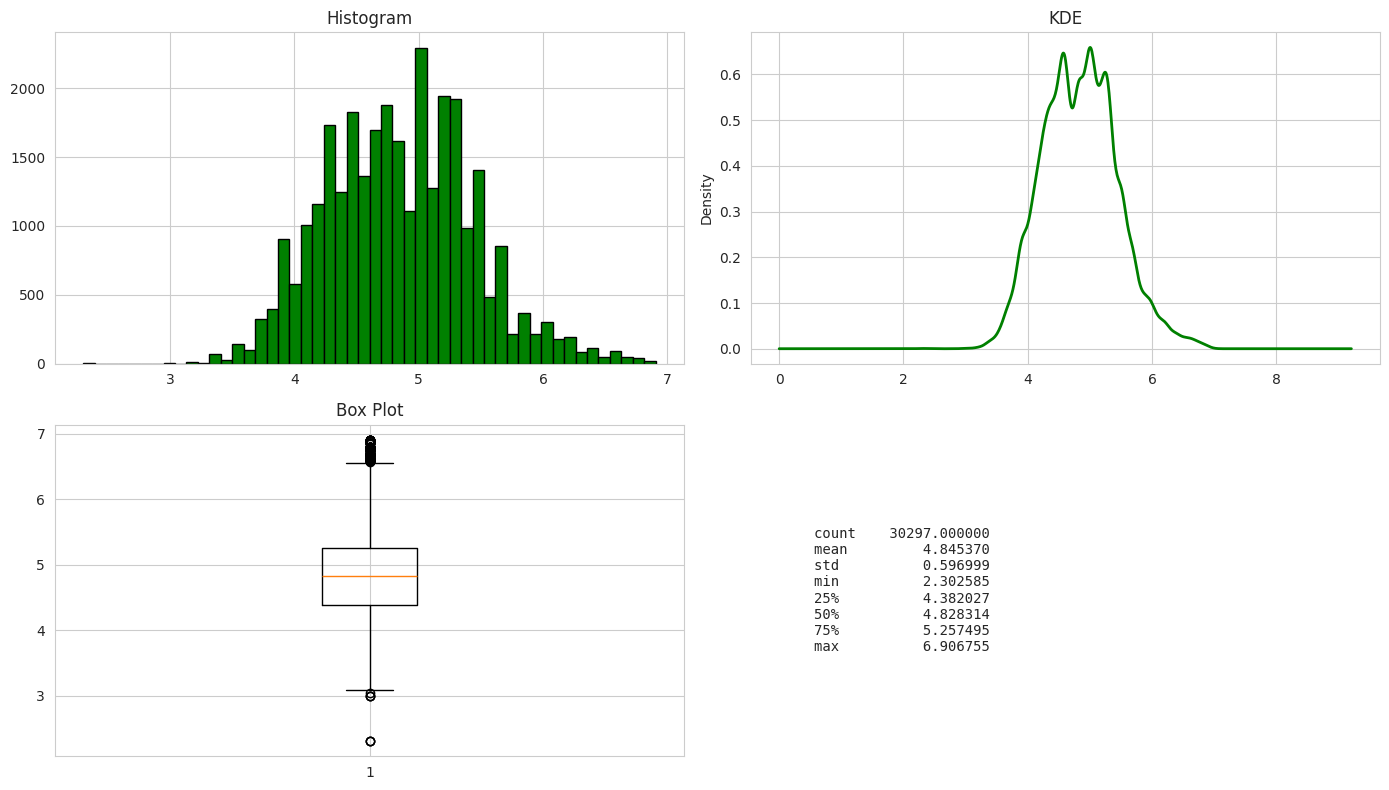

In [18]:
# Log transformation - convert Price to numeric first
airbnb['Price'] = pd.to_numeric(airbnb['Price'], errors='coerce')
airbnb['price_log'] = np.log(airbnb['Price'])

# Remove any inf or NaN values that result from log transformation
airbnb_clean = airbnb[np.isfinite(airbnb['price_log'])]

print("Log(Price):")
print(airbnb_clean['price_log'].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(airbnb_clean['price_log'], bins=50, edgecolor='black', color='green')
axes[0, 0].set_title('Histogram')

airbnb_clean['price_log'].plot(kind='kde', ax=axes[0, 1], linewidth=2, color='green')
axes[0, 1].set_title('KDE')

axes[1, 0].boxplot(airbnb_clean['price_log'])
axes[1, 0].set_title('Box Plot')

axes[1, 1].text(0.1, 0.5, airbnb_clean['price_log'].describe().to_string(),
                fontsize=10, family='monospace', verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Log(Price):
count    30297.000000
mean         4.845370
std          0.596999
min          2.302585
25%          4.382027
50%          4.828314
75%          5.257495
max          6.906755
Name: price_log, dtype: float64


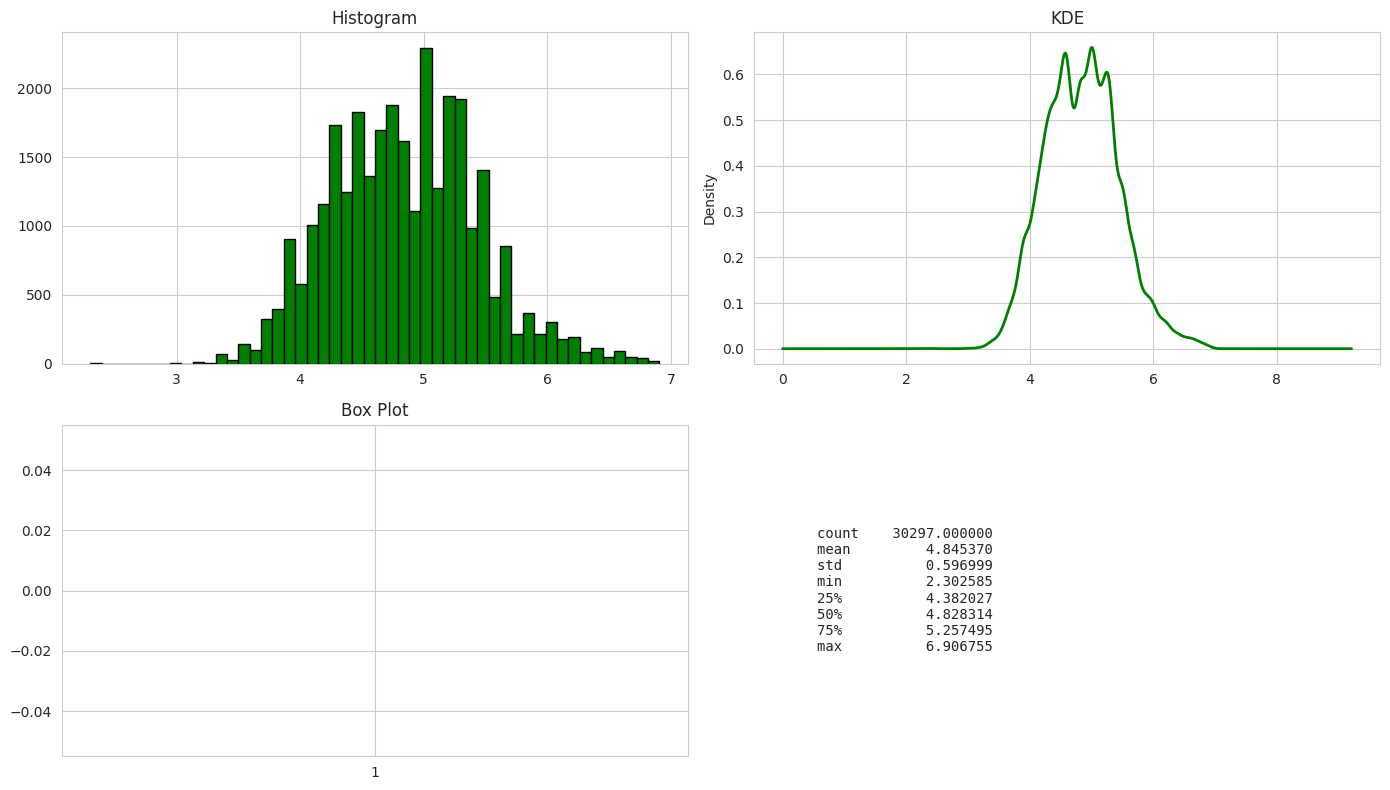


Log transformation: Much more symmetric, fewer extreme outliers.


In [19]:
# Log transformation
airbnb['price_log'] = np.log(airbnb['Price'])

print("Log(Price):")
print(airbnb['price_log'].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(airbnb['price_log'], bins=50, edgecolor='black', color='green')
axes[0, 0].set_title('Histogram')

airbnb['price_log'].plot(kind='kde', ax=axes[0, 1], linewidth=2, color='green')
axes[0, 1].set_title('KDE')

axes[1, 0].boxplot(airbnb['price_log'])
axes[1, 0].set_title('Box Plot')

axes[1, 1].text(0.1, 0.5, airbnb['price_log'].describe().to_string(),
                fontsize=10, family='monospace', verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nLog transformation: Much more symmetric, fewer extreme outliers.")

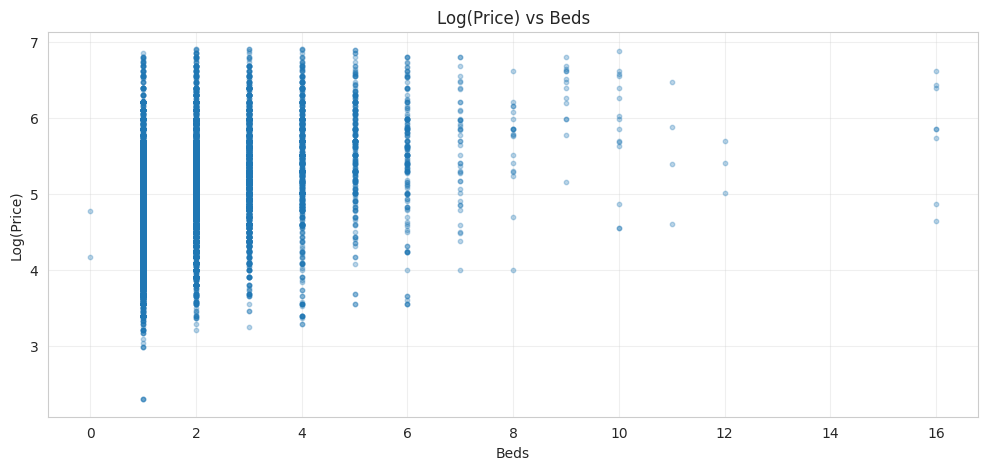


Price by number of Beds:
        count        mean         std    min     25%    50%     75%    max
Beds                                                                      
0.0       2.0   92.000000   38.183766   65.0   78.50   92.0  105.50  119.0
1.0   20307.0  124.757670   75.685752   10.0   75.00  100.0  155.00  950.0
2.0    6561.0  186.702332  115.044205   25.0  115.00  160.0  225.00  999.0
3.0    2029.0  234.928043  142.288189   26.0  140.00  200.0  299.00  999.0
4.0     766.0  280.554830  175.512312   27.0  150.00  240.0  363.75  999.0
5.0     274.0  322.000000  190.319415   35.0  186.00  285.0  425.00  995.0
6.0     166.0  316.313253  201.157585   35.0  183.75  271.0  399.00  900.0
7.0      45.0  341.377778  220.116631   55.0  177.00  300.0  445.00  900.0
8.0      20.0  331.850000  155.652202   55.0  218.75  339.5  408.75  750.0
9.0      14.0  587.142857  208.351721  175.0  423.75  625.0  750.00  900.0
10.0     15.0  442.200000  263.926992   95.0  287.00  400.0  650.00  975.0

In [20]:
# 3.5: Scatterplot and groupby
plt.figure(figsize=(12, 5))
plt.scatter(airbnb['Beds'], airbnb['price_log'], alpha=0.3, s=10)
plt.xlabel('Beds')
plt.ylabel('Log(Price)')
plt.title('Log(Price) vs Beds')
plt.grid(alpha=0.3)
plt.show()

print("\nPrice by number of Beds:")
print(airbnb.groupby('Beds')['Price'].describe())

print("\nPattern: Positive relationship. Mean and std both increase with beds.")

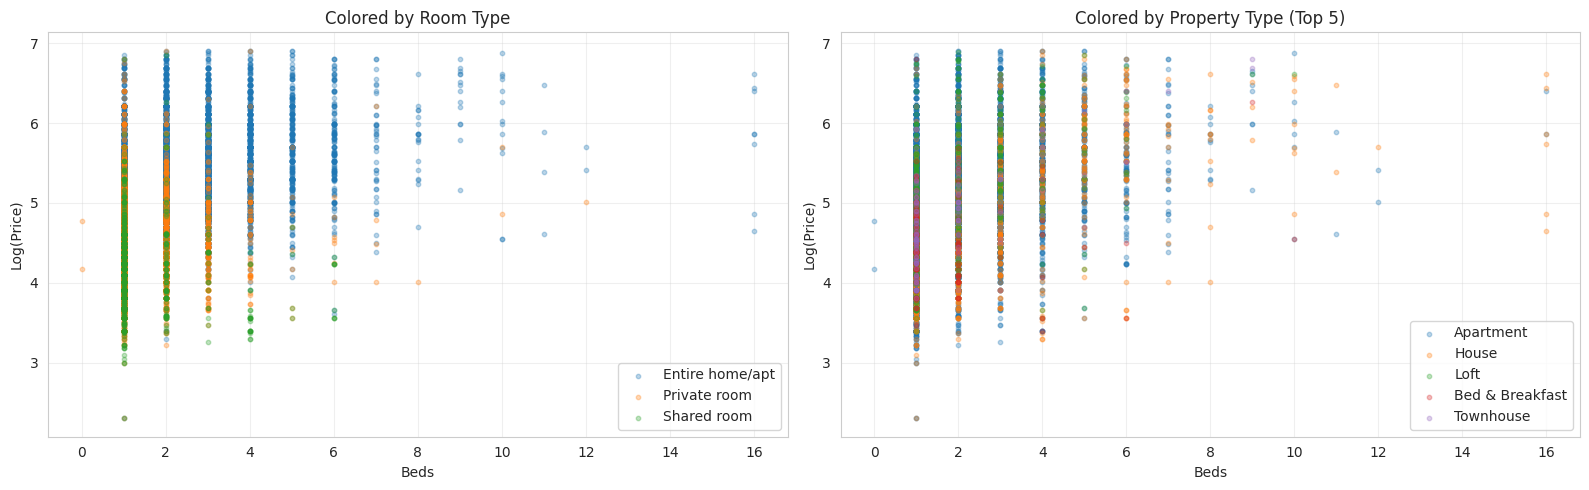


By Room Type:
                       mean         std
Room Type                              
Entire home/apt  204.061525  116.531136
Private room      90.663227   47.914195
Shared room       76.553974   65.756210

By Property Type (Top 10):
                     mean         std
Property Type                        
Condominium    237.946237  172.754121
Other          201.166667  183.231150
Loft           193.166667  169.094068
Townhouse      179.365672  152.097295
Cabin          165.000000  120.208153
Villa          160.571429   83.908397
Apartment      153.863170  104.112805
Boat           153.625000   49.231051
Bungalow       150.750000   46.464144
Castle         150.000000         NaN

Median more reliable than mean due to right skew and outliers.


In [21]:
# 3.6: Color by Room Type and Property Type
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By Room Type
for room_type in airbnb['Room Type'].unique():
    subset = airbnb[airbnb['Room Type'] == room_type]
    axes[0].scatter(subset['Beds'], subset['price_log'], alpha=0.3, s=10, label=room_type)
axes[0].set_xlabel('Beds')
axes[0].set_ylabel('Log(Price)')
axes[0].set_title('Colored by Room Type')
axes[0].legend()
axes[0].grid(alpha=0.3)

# By Property Type (top 5)
top_props = airbnb['Property Type'].value_counts().head(5).index
for prop in top_props:
    subset = airbnb[airbnb['Property Type'] == prop]
    axes[1].scatter(subset['Beds'], subset['price_log'], alpha=0.3, s=10, label=prop)
axes[1].set_xlabel('Beds')
axes[1].set_ylabel('Log(Price)')
axes[1].set_title('Colored by Property Type (Top 5)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBy Room Type:")
print(airbnb.groupby('Room Type')['Price'].describe()[['mean', 'std']])

print("\nBy Property Type (Top 10):")
print(airbnb.groupby('Property Type')['Price'].describe()[['mean', 'std']].sort_values('mean', ascending=False).head(10))

print("\nMedian more reliable than mean due to right skew and outliers.")

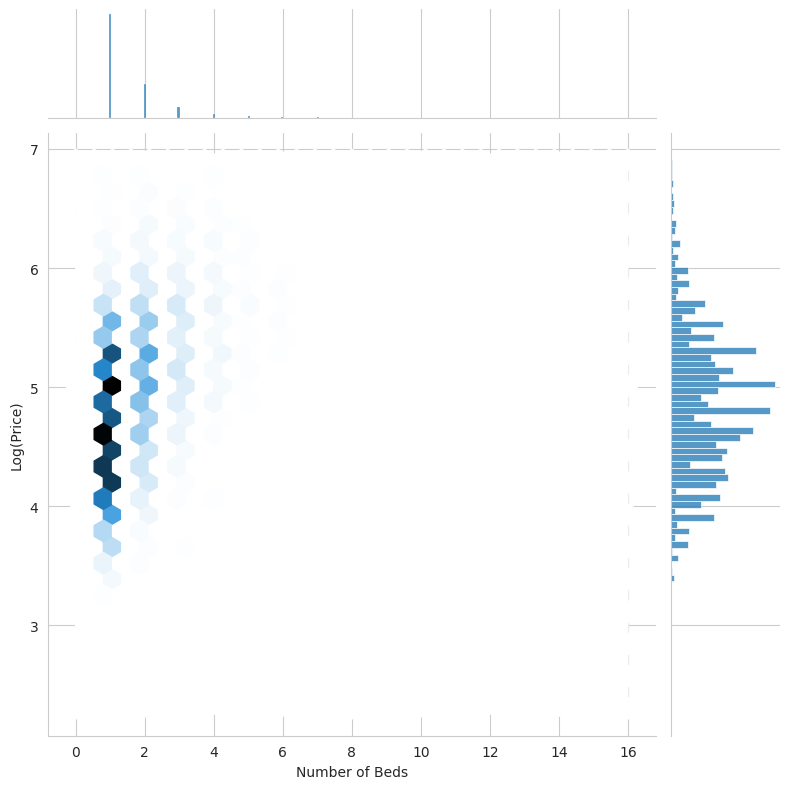


Hexbin reveals: Vast majority of data at 1-2 beds. High bed counts are sparse.
Effect: Patterns at 5+ beds less reliable due to small sample size.
% with ≤2 beds: 88.4%


In [22]:
# 3.7: Jointplot with hexbin
g = sns.jointplot(data=airbnb, x='Beds', y='price_log', kind='hex', height=8, gridsize=30)
g.set_axis_labels('Number of Beds', 'Log(Price)')
plt.tight_layout()
plt.show()

print("\nHexbin reveals: Vast majority of data at 1-2 beds. High bed counts are sparse.")
print("Effect: Patterns at 5+ beds less reliable due to small sample size.")
print(f"% with ≤2 beds: {(airbnb['Beds'] <= 2).sum() / len(airbnb) * 100:.1f}%")

## Q4: Drilling Rigs Time Series

In [23]:
# 4.1: Load and examine
rigs = pd.read_csv('/content/drilling_rigs.csv')
print(f"Observations: {rigs.shape[0]}, Variables: {rigs.shape[1]}")
print("\nFirst rows:")
print(rigs.head())
print("\nData types:")
print(rigs.dtypes)

print("\nCleaning needed:")
print("1. Month column: Convert to datetime")
print("2. Numeric columns: 'Not Available' values need conversion to NaN")
print("3. Cast numeric columns from object to float/int")

Observations: 623, Variables: 10

First rows:
           Month  \
0   1973 January   
1  1973 February   
2     1973 March   
3     1973 April   
4       1973 May   

   Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)  \
0                                               1120                              
1                                               1037                              
2                                                959                              
3                                                914                              
4                                                974                              

   Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)  \
0                                                 99                               
1                                                 89                               
2                                                 90                              

In [24]:
# 4.2: Convert Month to datetime
rigs['time'] = pd.to_datetime(rigs['Month'], format='mixed')
print(f"Date range: {rigs['time'].min()} to {rigs['time'].max()}")

Date range: 1973-01-01 00:00:00 to 2024-11-01 00:00:00


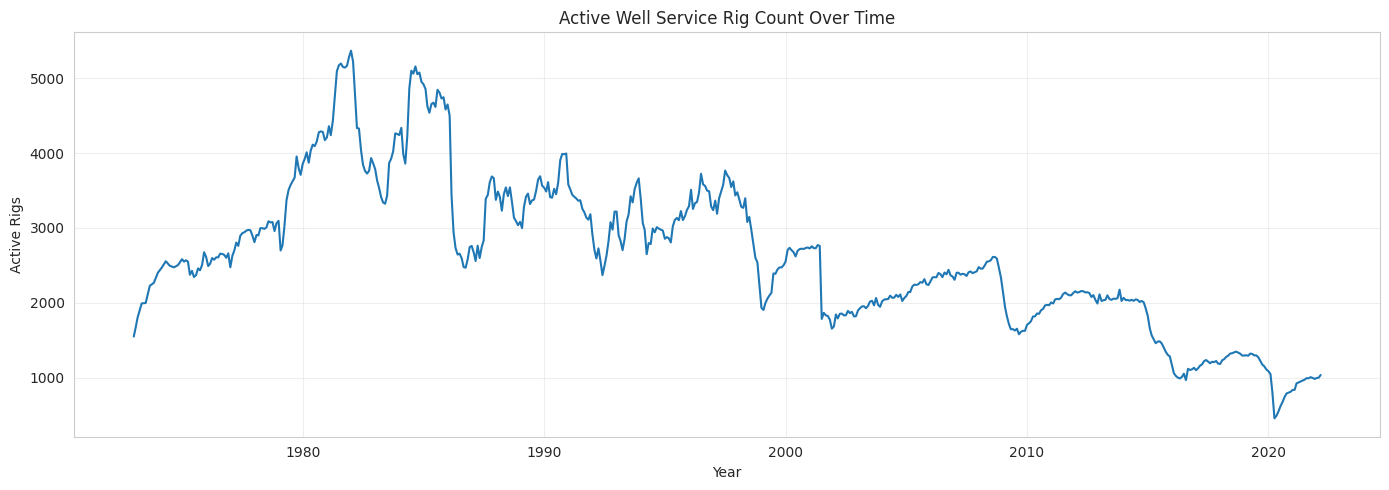


Observations:
- Sharp increase 1970s to early 1980s peak
- Dramatic decline through 1980s
- Relatively stable at lower levels since ~1990
Peak: 5367, Minimum: 456


In [25]:
# 4.3: Line plot of Active Well Service Rig Count
rigs['Active_Rigs'] = pd.to_numeric(rigs['Active Well Service Rig Count (Number of Rigs)'], errors='coerce')

plt.figure(figsize=(14, 5))
plt.plot(rigs['time'], rigs['Active_Rigs'], linewidth=1.5)
plt.xlabel('Year')
plt.ylabel('Active Rigs')
plt.title('Active Well Service Rig Count Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Sharp increase 1970s to early 1980s peak")
print("- Dramatic decline through 1980s")
print("- Relatively stable at lower levels since ~1990")
print(f"Peak: {rigs['Active_Rigs'].max():.0f}, Minimum: {rigs['Active_Rigs'].min():.0f}")

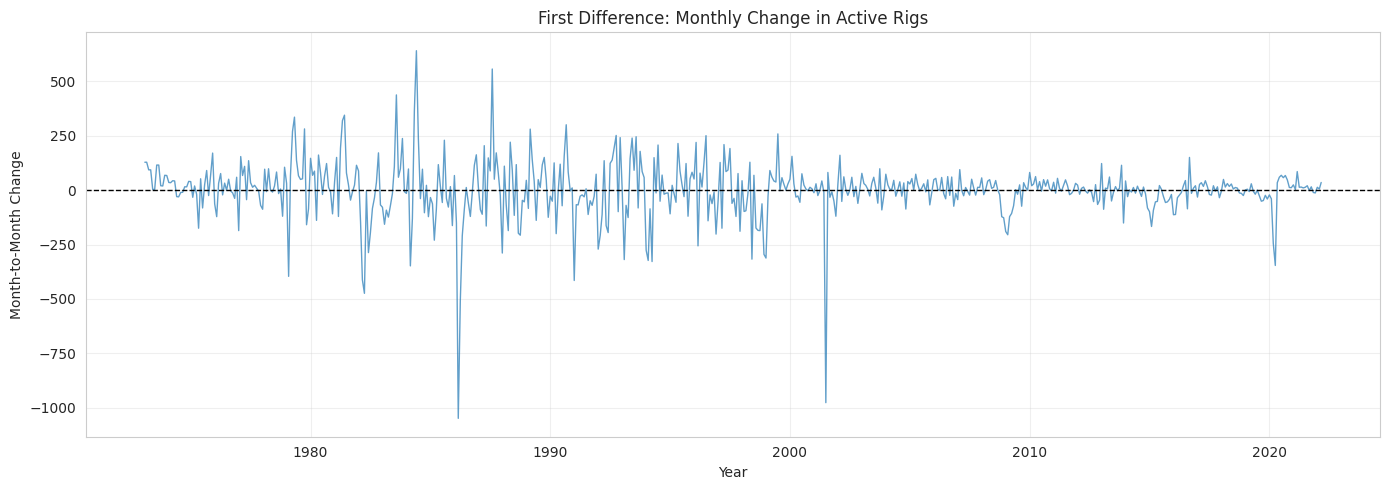


Observations:
- Extreme volatility in 1970s-1980s
- Much smaller fluctuations in recent decades
- Oscillates around zero (stationary)
Largest increase: 640
Largest decrease: -1048


In [26]:
# 4.4: First difference
rigs['Active_Rigs_Diff'] = rigs['Active_Rigs'].diff()

plt.figure(figsize=(14, 5))
plt.plot(rigs['time'], rigs['Active_Rigs_Diff'], linewidth=1, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Month-to-Month Change')
plt.title('First Difference: Monthly Change in Active Rigs')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Extreme volatility in 1970s-1980s")
print("- Much smaller fluctuations in recent decades")
print("- Oscillates around zero (stationary)")
print(f"Largest increase: {rigs['Active_Rigs_Diff'].max():.0f}")
print(f"Largest decrease: {rigs['Active_Rigs_Diff'].min():.0f}")

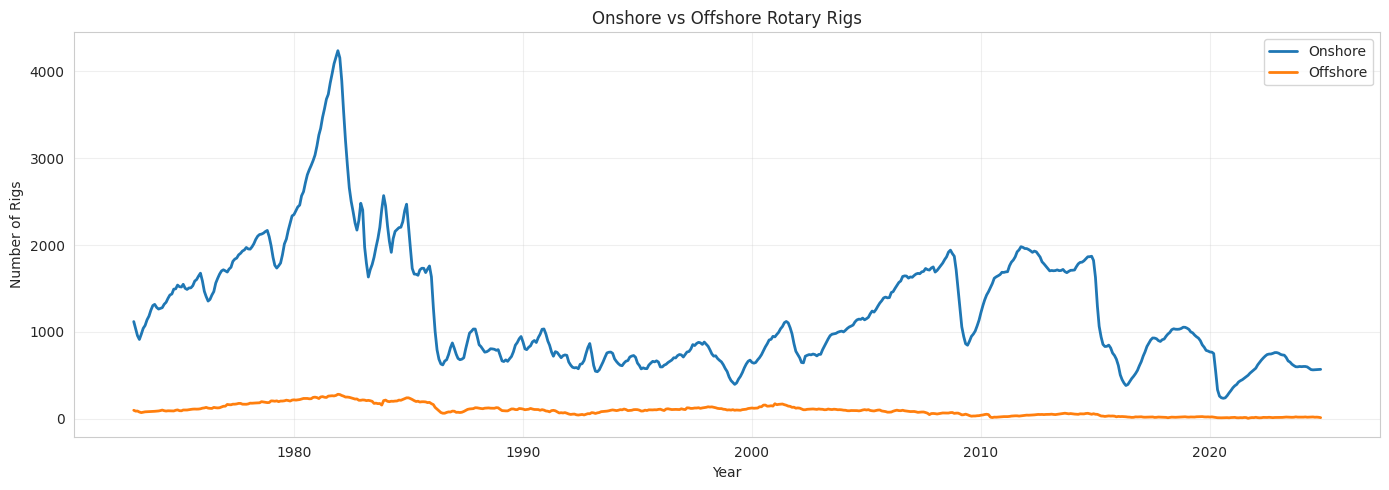


Comparison:
Onshore max: 4238
Offshore max: 283
Both show boom-bust cycles, but onshore declined more dramatically after 1980s.


In [27]:
# 4.5: Melt and plot onshore vs offshore
rigs['Onshore'] = pd.to_numeric(rigs['Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)'], errors='coerce')
rigs['Offshore'] = pd.to_numeric(rigs['Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)'], errors='coerce')

# Melt
melted = rigs[['time', 'Onshore', 'Offshore']].melt(id_vars='time', var_name='Location', value_name='Rig_Count')

# Plot
plt.figure(figsize=(14, 5))
for location in ['Onshore', 'Offshore']:
    data = melted[melted['Location'] == location]
    plt.plot(data['time'], data['Rig_Count'], linewidth=2, label=location)

plt.xlabel('Year')
plt.ylabel('Number of Rigs')
plt.title('Onshore vs Offshore Rotary Rigs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nComparison:")
print(f"Onshore max: {rigs['Onshore'].max():.0f}")
print(f"Offshore max: {rigs['Offshore'].max():.0f}")
print("Both show boom-bust cycles, but onshore declined more dramatically after 1980s.")